# SDC New Issues — Equity & Debt Issuance EDA

Annual counts of US securities offerings from SDC New Issues and FISD/Mergent.

**Data sources:**
- SDC Global New Issues (`tr_sdc_ni.wrds_ni_details`)
- FISD/Mergent (`fisd_fisd.fisd_mergedissue`) for registered + 144A corporate bonds

**Reference:** `references/sdc-issuances.md`, `references/fisd-bonds.md`

## Contents
1. Schema discovery
2. SDC equity issuances: IPOs vs SEOs, annual counts
3. FISD bond issuances: IG vs HY, 144A vs registered
4. 144A share over time
5. Summary: capital markets practice area sizing

In [1]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

conn = psycopg2.connect(
    host='wrds-pgdata.wharton.upenn.edu',
    port=9737,
    database='wrds',
    user='eddyhu',
    sslmode='require'
)
print('Connected to WRDS')

Connected to WRDS


## 1. Schema Discovery

In [2]:
cur = conn.cursor()

# Confirm SDC schemas
cur.execute("""
    SELECT schema_name
    FROM information_schema.schemata
    WHERE schema_name ILIKE '%tr_sdc%'
    ORDER BY schema_name
""")
print('SDC schemas:', cur.fetchall())

# Confirmed: tr_sdc_ni = New Issues, tr_sdc_ma = M&A
SDC_NI_SCHEMA = 'tr_sdc_ni'
NI_TABLE = 'tr_sdc_ni.wrds_ni_details'
print(f'New Issues table: {NI_TABLE}')

SDC schemas: [('tr_sdc_ma',), ('tr_sdc_ma_old',), ('tr_sdc_ni',), ('tr_sdc_ni_old',), ('tr_sdc_samples',), ('tr_sdc_samples_new',)]
New Issues table: tr_sdc_ni.wrds_ni_details


In [3]:
# List tables in SDC NI schema
cur.execute("""
    SELECT table_name,
           pg_size_pretty(pg_total_relation_size(
               quote_ident(table_schema)||'.'||quote_ident(table_name))) AS size
    FROM information_schema.tables
    WHERE table_schema = 'tr_sdc_ni'
    ORDER BY table_name
""")
print('Tables in tr_sdc_ni:')
for t in cur.fetchall():
    print(' ', t)

Tables in tr_sdc_ni:
  ('wrds_ni_details', '999 MB')
  ('wrds_ni_events', '439 MB')
  ('wrds_ni_managers', '533 MB')
  ('wrds_ni_related', '1296 kB')
  ('wrds_ni_sharehlds', '6328 kB')


In [4]:
# Row count and date range check
cur.execute("""
    SELECT
        COUNT(*)                          AS total_rows,
        COUNT(DISTINCT master_deal_no)    AS unique_deals,
        MIN(master_deal_date)             AS earliest,
        MAX(master_deal_date)             AS latest
    FROM tr_sdc_ni.wrds_ni_details
""")
row = cur.fetchone()
print(f'Total rows:     {row[0]:,.0f}')
print(f'Unique deals:   {row[1]:,.0f}')
print(f'Date range:     {row[2]} → {row[3]}')

Total rows:     1,697,175
Unique deals:   1,697,175
Date range:     1962-08-30 → 2026-04-01


In [5]:
# Sample IPO flag and security type values
cur.execute("""
    SELECT ipo, COUNT(*) FROM tr_sdc_ni.wrds_ni_details
    GROUP BY ipo ORDER BY COUNT(*) DESC LIMIT 10
""")
print('IPO flag values:')
for r in cur.fetchall(): print(f'  {r[0]!r:<20} {r[1]:,}')

print()
cur.execute("""
    SELECT security, COUNT(*) FROM tr_sdc_ni.wrds_ni_details
    WHERE nation = 'United States'
    GROUP BY security ORDER BY COUNT(*) DESC LIMIT 20
""")
print('Top security types (US):')
for r in cur.fetchall(): print(f'  {r[0]!r:<40} {r[1]:,}')

IPO flag values:
  None                 1,285,549
  'No'                 297,967
  'Yes'                113,659



Top security types (US):
  'Bonds'                                  65,618
  'Medium-Term Nts'                        64,904
  'Common Shares'                          49,635
  'Pass-Thru Certs'                        44,025
  'Asset Bkd Certs'                        39,885
  'Fxd/Straight Bd'                        29,445
  'Gtd Pass Certs'                         26,930
  'Gtd Part Certs'                         23,636
  'Senior Notes'                           21,156
  'CDs'                                    16,642
  'Mdm-Trm Fl Nts'                         16,123
  'Notes'                                  15,015
  'Global Notes'                           11,978
  'Mtg Bkd Certs'                          11,880
  'Comm Mtg PT Crt'                        10,697
  'Coll Loan Oblig'                        10,354
  'Step-Up Bonds'                          10,213
  'Step-Up MTN'                            9,407
  'Senior Bonds'                           8,851
  'Global Bonds'           

## 2. SDC Equity Issuances: IPOs vs SEOs

In [6]:
# Pull US new issues (equity)
query_equity = """
SELECT
    master_deal_no,
    master_deal_date,
    EXTRACT(YEAR FROM master_deal_date)::int AS issue_year,
    ninames             AS issuer,
    nation,
    ipo                 AS ipo_flag,
    offerpric           AS offer_price,
    totdolamt           AS proceeds_mm,
    security            AS security_type,
    description,
    cusip9,
    exchange
FROM tr_sdc_ni.wrds_ni_details
WHERE nation = 'United States'
  AND master_deal_date BETWEEN '1985-01-01' AND '2026-12-31'
  AND totdolamt IS NOT NULL
  AND totdolamt > 0
"""
df_eq = pd.read_sql(query_equity, conn)
df_eq['offer_price_num'] = pd.to_numeric(df_eq['offer_price'], errors='coerce')
print(f'Raw US rows: {len(df_eq):,}')
print('IPO flag distribution:')
print(df_eq['ipo_flag'].value_counts(dropna=False).head(5))
df_eq.head(3)

/Users/vwh7mb/.tmp/ipykernel_60759/3918131285.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_eq = pd.read_sql(query_equity, conn)


Raw US rows: 609,933
IPO flag distribution:
ipo_flag
None    560476
No       32784
Yes      16673
Name: count, dtype: int64


,master_deal_no,master_deal_date,issue_year,issuer,nation,ipo_flag,offer_price,proceeds_mm,security_type,description,cusip9,exchange,offer_price_num
0,1000001001,2000-04-25,2000,Credit Agricole (New York),United States,None,Market,320.000,CDs,6.820% CDs due '01,22531AKZ1,None,NaN
1,1000002,1985-09-10,1985,"Somerset Bancorp,Somerville,NJ",United States,No,19.750,5.925,Common Shares,"300,000.0 Common Shares",None,Nasdaq,19.75
2,1000003001,2000-04-25,2000,"LaSalle Bank NA,Chicago,IL",United States,None,100.000,5.000,Deposit Notes,7.250% Deposit Notes due '12,51803MDM2,None,100.00


In [7]:
# Standard cleaning filters
EXCLUDE_TYPES = {
    'Units', 'Ltd Prtnr Int', 'MLP-Common Shs',
    'Shs Benficl Int', 'Ltd Liab Int', 'Stock Unit',
    'Trust Units', 'Beneficial Ints', 'Preferred Stock'
}
EXCLUDE_DESCR = [
    'reit', 'real estate investment', 'depositary',
    'closed-end fund', 'unit trust'
]
excl_mask = df_eq['description'].fillna('').str.lower().str.contains(
    '|'.join(EXCLUDE_DESCR), regex=True
)

# IPOs
df_ipo = df_eq[
    (df_eq['ipo_flag'] == 'Yes') &
    (~df_eq['security_type'].isin(EXCLUDE_TYPES)) &
    (~excl_mask) &
    (df_eq['offer_price_num'] >= 5.0)
].copy()

# SEOs
df_seo = df_eq[
    (df_eq['ipo_flag'] == 'No') &
    (~df_eq['security_type'].isin(EXCLUDE_TYPES)) &
    (~excl_mask) &
    (df_eq['offer_price_num'] >= 1.0)
].copy()

print(f'Clean IPOs:  {len(df_ipo):,}')
print(f'Clean SEOs:  {len(df_seo):,}')

Clean IPOs:  11,547
Clean SEOs:  22,816


In [8]:
# Annual IPO and SEO counts
ipo_annual = df_ipo.groupby('issue_year').agg(
    n_ipos=('master_deal_no', 'count'),
    proceeds_bn=('proceeds_mm', lambda x: x.sum() / 1e3)
)
seo_annual = df_seo.groupby('issue_year').agg(
    n_seos=('master_deal_no', 'count'),
    proceeds_bn=('proceeds_mm', lambda x: x.sum() / 1e3)
)

equity_annual = ipo_annual.join(
    seo_annual, how='outer', lsuffix='_ipo', rsuffix='_seo'
).fillna(0)
equity_annual = equity_annual[(equity_annual.index >= 1985) & (equity_annual.index <= 2026)]
print(equity_annual.tail(10))

            n_ipos  proceeds_bn_ipo  n_seos  proceeds_bn_seo
issue_year                                                  
2017           136        27.122448     655       127.971021
2018           152        31.190063     607       122.785522
2019           127        41.874063     520       113.807199
2020           183        67.929779     784       203.117319
2021           335       124.200275     798       311.442593
2022            42         7.576806     335        54.126955
2023            47        10.275984     569        88.163596
2024            80        25.722394     625       293.026956
2025            89        38.574430     636       258.070313
2026            25         8.500634     154        66.335802


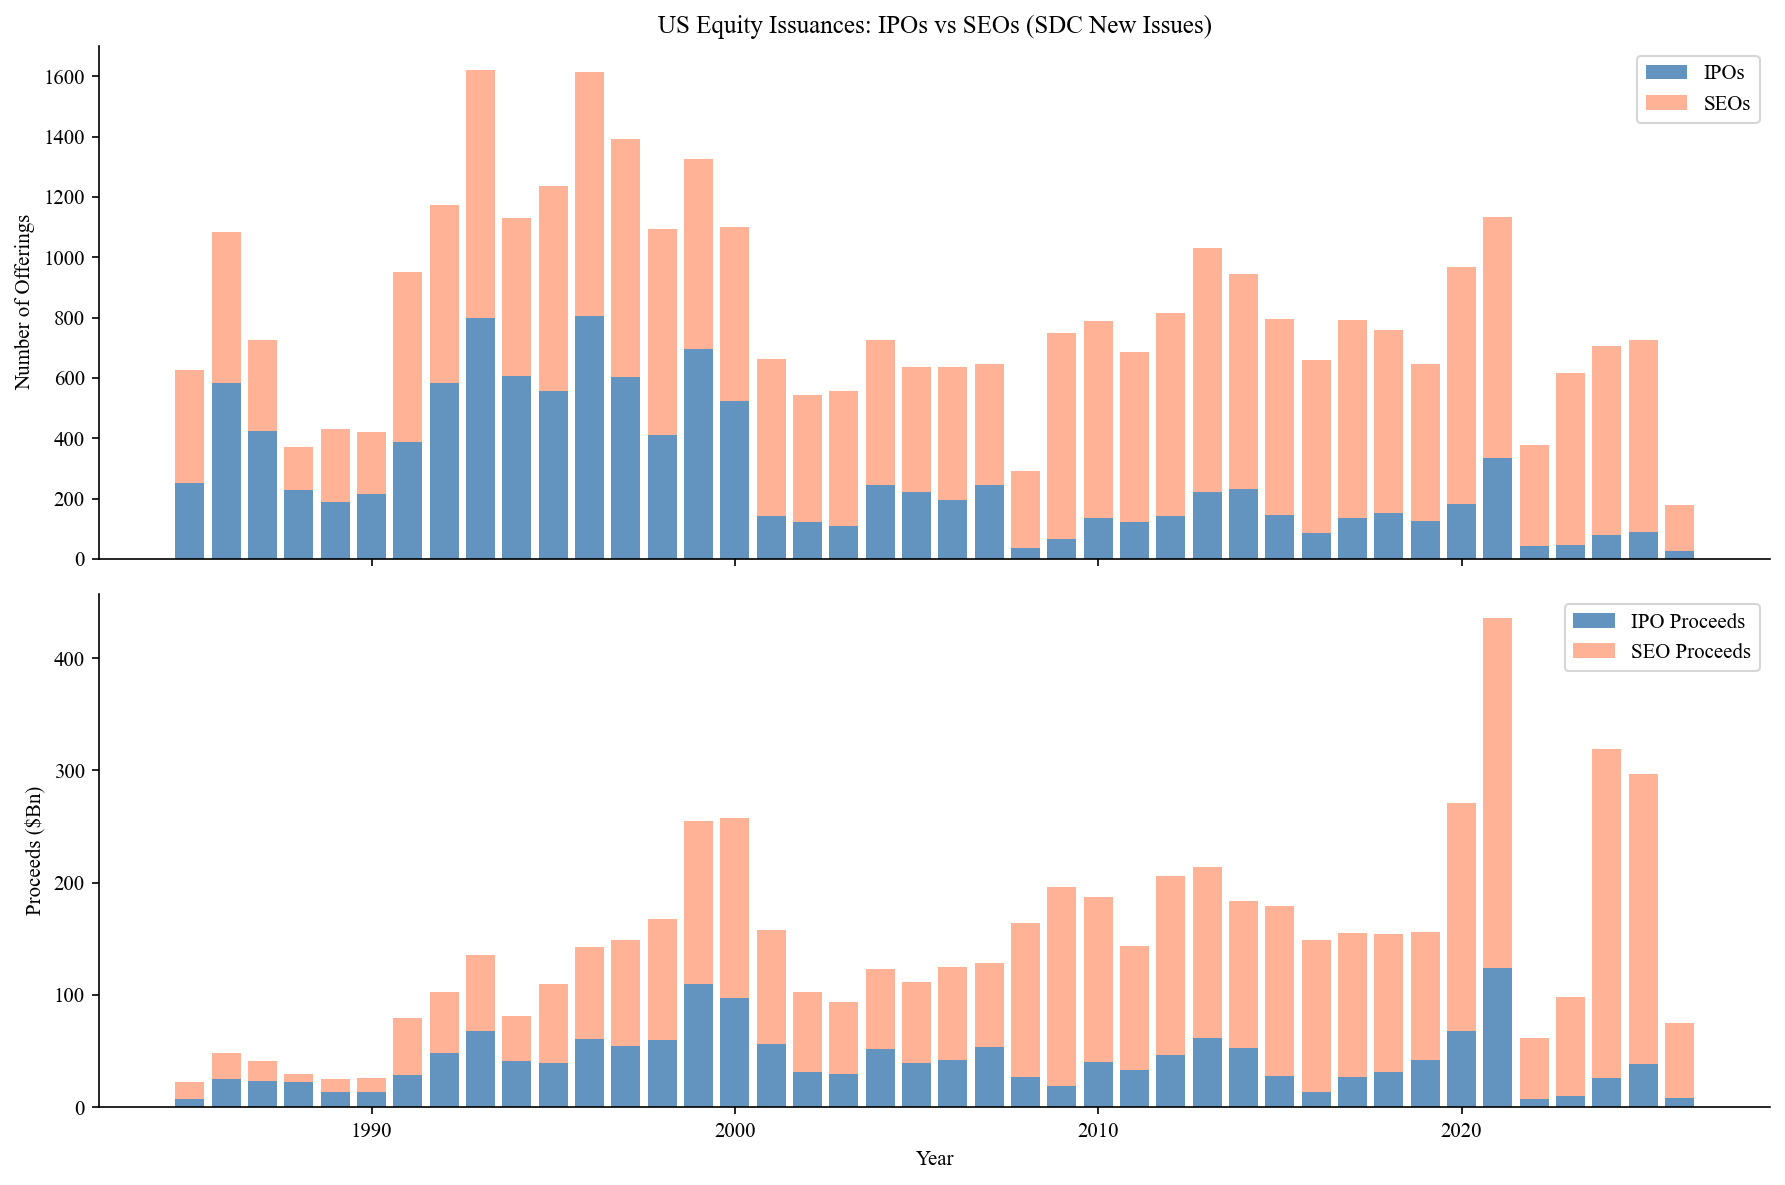

Saved: /tmp/equity_issuances.png


In [9]:
# Plot IPO vs SEO counts
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax0, ax1 = axes
ax0.bar(equity_annual.index, equity_annual['n_ipos'], color='steelblue',
        label='IPOs', alpha=0.85)
ax0.bar(equity_annual.index, equity_annual['n_seos'],
        bottom=equity_annual['n_ipos'],
        color='coral', alpha=0.6, label='SEOs')
ax0.set_ylabel('Number of Offerings')
ax0.set_title('US Equity Issuances: IPOs vs SEOs (SDC New Issues)')
ax0.legend()

ax1.bar(equity_annual.index, equity_annual['proceeds_bn_ipo'],
        color='steelblue', label='IPO Proceeds', alpha=0.85)
ax1.bar(equity_annual.index, equity_annual['proceeds_bn_seo'],
        bottom=equity_annual['proceeds_bn_ipo'],
        color='coral', alpha=0.6, label='SEO Proceeds')
ax1.set_ylabel('Proceeds ($Bn)')
ax1.set_xlabel('Year')
ax1.legend()

plt.tight_layout()
plt.savefig('/tmp/equity_issuances.png', dpi=150, bbox_inches='tight')
plt.savefig('/tmp/equity_issuances.svg', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /tmp/equity_issuances.png')

## 3. FISD Bond Issuances: IG vs HY, 144A vs Registered

In [10]:
# FISD schema: fisd_fisd (confirmed from schema inventory)
# Note: ratings are in fisd_ratings table (rating_type: MR=Moody's, SPR=S&P)
query_bonds = """
SELECT
    EXTRACT(YEAR FROM i.offering_date)::int  AS issue_year,
    i.rule_144a,
    COALESCE(
        -- Use first available S&P rating at/after offering date
        MAX(CASE WHEN r.rating_type = 'SPR' THEN
            CASE
                WHEN r.rating IN ('AAA','AA+','AA','AA-','A+','A','A-',
                                   'BBB+','BBB','BBB-') THEN 'IG'
                WHEN r.rating IN ('BB+','BB','BB-','B+','B','B-',
                                   'CCC+','CCC','CCC-','CC','C','D') THEN 'HY'
                ELSE NULL
            END
        END),
        MAX(CASE WHEN r.rating_type = 'MR' THEN
            CASE
                WHEN r.rating IN ('Aaa','Aa1','Aa2','Aa3',
                                   'A1','A2','A3','Baa1','Baa2','Baa3') THEN 'IG'
                WHEN r.rating IN ('Ba1','Ba2','Ba3','B1','B2','B3',
                                   'Caa1','Caa2','Caa3','Ca','C') THEN 'HY'
                ELSE NULL
            END
        END),
        'NR'
    )                                        AS rating_cat,
    COUNT(DISTINCT i.issue_id)              AS n_issues,
    SUM(i.offering_amt) / 1e3              AS proceeds_bn
FROM fisd_fisd.fisd_mergedissue i
JOIN fisd_fisd.fisd_mergedissuer u ON i.issuer_id = u.issuer_id
LEFT JOIN fisd_fisd.fisd_ratings r
    ON r.issue_id = i.issue_id
    AND r.rating_type IN ('SPR', 'MR')
    AND r.rating_date BETWEEN i.offering_date - INTERVAL '90 days' AND i.offering_date + INTERVAL '90 days'
WHERE u.country_domicile = 'USA'
  AND i.bond_type IN ('CDEB','CMTN','CMTZ','CZ','USBN')
  AND (i.yankee = 'N' OR i.yankee IS NULL)
  AND (i.canadian = 'N' OR i.canadian IS NULL)
  AND (i.foreign_currency = 'N' OR i.foreign_currency IS NULL)
  AND (i.asset_backed = 'N' OR i.asset_backed IS NULL)
  AND (i.convertible = 'N' OR i.convertible IS NULL)
  AND (i.preferred_security = 'N' OR i.preferred_security IS NULL)
  AND (i.defeased = 'N' OR i.defeased IS NULL)
  AND i.offering_date BETWEEN '1990-01-01' AND '2026-12-31'
  AND i.offering_amt > 0
GROUP BY issue_year, i.rule_144a, i.issue_id, i.offering_amt
"""
# Note: this query can be slow due to the ratings join; use subquery approach for production
# Simpler alternative: group without ratings for deal counts, add IG/HY in post-processing
query_bonds_simple = """
SELECT
    EXTRACT(YEAR FROM i.offering_date)::int  AS issue_year,
    i.rule_144a,
    i.bond_type,
    COUNT(*)                                 AS n_issues,
    SUM(i.offering_amt) / 1e3               AS proceeds_bn
FROM fisd_fisd.fisd_mergedissue i
JOIN fisd_fisd.fisd_mergedissuer u ON i.issuer_id = u.issuer_id
WHERE u.country_domicile = 'USA'
  AND i.bond_type IN ('CDEB','CMTN','CMTZ','CZ','USBN')
  AND (i.yankee = 'N' OR i.yankee IS NULL)
  AND (i.canadian = 'N' OR i.canadian IS NULL)
  AND (i.foreign_currency = 'N' OR i.foreign_currency IS NULL)
  AND (i.asset_backed = 'N' OR i.asset_backed IS NULL)
  AND (i.convertible = 'N' OR i.convertible IS NULL)
  AND (i.preferred_security = 'N' OR i.preferred_security IS NULL)
  AND (i.defeased = 'N' OR i.defeased IS NULL)
  AND i.offering_date BETWEEN '1990-01-01' AND '2026-12-31'
  AND i.offering_amt > 0
GROUP BY issue_year, i.rule_144a, i.bond_type
ORDER BY issue_year, i.rule_144a
"""
df_bonds = pd.read_sql(query_bonds_simple, conn)
print(f'Bond issuance rows: {len(df_bonds):,}')
df_bonds.head(8)

/Users/vwh7mb/.tmp/ipykernel_60759/1373952538.py:75: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_bonds = pd.read_sql(query_bonds_simple, conn)


Bond issuance rows: 266


,issue_year,rule_144a,bond_type,n_issues,proceeds_bn
0,1990,N,CZ,1,2250.0000
1,1990,N,CMTN,112,1709.6550
2,1990,N,CDEB,381,67198.9020
3,1991,N,CZ,2,973.0000
4,1991,N,CMTN,518,7674.5250
5,1991,N,CDEB,637,115371.6714
6,1991,Y,CZ,1,256.3650
7,1991,Y,CDEB,3,226.5390


In [11]:
# Pivot to wide format: bond_type x 144A/Reg
df_bonds['reg_type'] = df_bonds['rule_144a'].map({'Y': '144A', 'N': 'Reg'}).fillna('Reg')

# Plain vanilla types: CDEB=debenture, CMTN=MTN, USBN=bank note, CZ/CMTZ=zero coupon
STRAIGHT_TYPES = {'CDEB', 'USBN', 'CZ', 'CMTZ'}
MTN_TYPES = {'CMTN'}
df_bonds['bond_cat'] = df_bonds['bond_type'].apply(
    lambda x: 'Straight' if x in STRAIGHT_TYPES else 'MTN'
)
df_bonds['category'] = df_bonds['bond_cat'] + '_' + df_bonds['reg_type']

bond_pivot = (
    df_bonds
    .groupby(['issue_year', 'category'])[['n_issues', 'proceeds_bn']]
    .sum()
    .unstack('category')
    .fillna(0)
)
bond_pivot = bond_pivot[((bond_pivot.index >= 1995) & (bond_pivot.index <= 2026))]
print('Categories:', bond_pivot.columns.get_level_values(1).unique().tolist())
print(bond_pivot['n_issues'].tail(5))

Categories: ['MTN_144A', 'MTN_Reg', 'Straight_144A', 'Straight_Reg']
category    MTN_144A  MTN_Reg  Straight_144A  Straight_Reg
issue_year                                                
2022            42.0   8921.0          280.0       11224.0
2023            42.0  10705.0          305.0       11974.0
2024            75.0  13992.0          482.0       14264.0
2025            48.0   6604.0          222.0        8525.0
2026             0.0      0.0            0.0           1.0


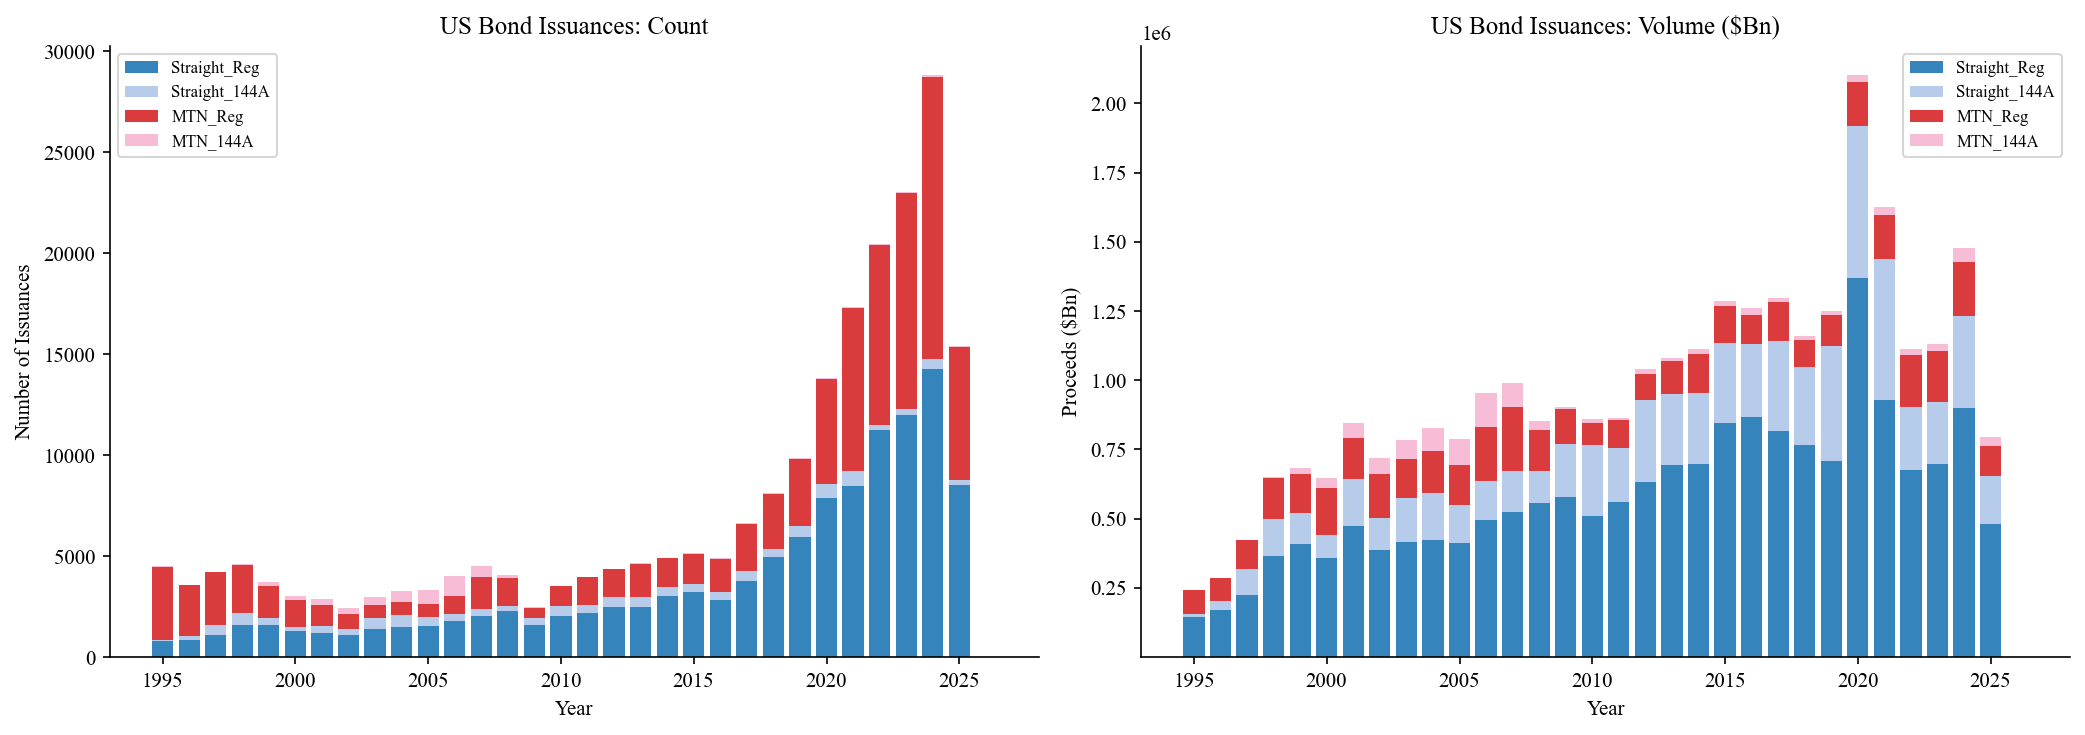

Saved: /tmp/bond_issuances.png


In [12]:
# Plot bond issuances by type and 144A/Reg
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cats = [c for c in ['Straight_Reg', 'Straight_144A', 'MTN_Reg', 'MTN_144A']
        if c in bond_pivot['n_issues'].columns]
colors = ['#1f77b4', '#aec7e8', '#d62728', '#f7b6d2']

for ax, metric, title in [
    (axes[0], 'n_issues', 'US Bond Issuances: Count'),
    (axes[1], 'proceeds_bn', 'US Bond Issuances: Volume ($Bn)')
]:
    data = bond_pivot[metric]
    bottom = np.zeros(len(data))
    for cat, col in zip(cats, colors):
        if cat in data.columns:
            ax.bar(data.index, data[cat], bottom=bottom,
                   label=cat, color=col, alpha=0.9)
            bottom += data[cat].values
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Number of Issuances')
axes[1].set_ylabel('Proceeds ($Bn)')

plt.tight_layout()
plt.savefig('/tmp/bond_issuances.png', dpi=150, bbox_inches='tight')
plt.savefig('/tmp/bond_issuances.svg', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /tmp/bond_issuances.png')

## 4. 144A Share of Bond Market Over Time

In [13]:
# 144A share by bond category
n = bond_pivot['n_issues']
for bc in ['Straight', 'MTN']:
    reg_col = f'{bc}_Reg'
    a44_col = f'{bc}_144A'
    if reg_col in n.columns and a44_col in n.columns:
        total = n[reg_col] + n[a44_col]
        share = (n[a44_col] / total.replace(0, float('nan')) * 100).fillna(0)
        print(f'{bc} 144A share (recent):')
        print(share.tail(10).round(1))
        print()

Straight 144A share (recent):
issue_year
2017    11.9
2018     7.7
2019     8.6
2020     8.1
2021     7.9
2022     2.4
2023     2.5
2024     3.3
2025     2.5
2026     0.0
dtype: float64

MTN 144A share (recent):
issue_year
2017    1.3
2018    0.9
2019    0.9
2020    0.9
2021    0.6
2022    0.5
2023    0.4
2024    0.5
2025    0.7
2026    0.0
dtype: float64



## 5. Summary: Capital Markets Practice Area Sizing

In [14]:
# Recent 5-year averages
recent_years = range(2019, 2024)

ipos_avg = equity_annual.loc[((equity_annual.index >= 2019) & (equity_annual.index <= 2023)), 'n_ipos'].mean()
seos_avg = equity_annual.loc[((equity_annual.index >= 2019) & (equity_annual.index <= 2023)), 'n_seos'].mean()

n = bond_pivot['n_issues']
years_mask = (n.index >= 2019) & (n.index <= 2023)
straight_144a_avg = n.loc[years_mask, 'Straight_144A'].mean() if 'Straight_144A' in n.columns else 0
straight_reg_avg  = n.loc[years_mask, 'Straight_Reg'].mean()  if 'Straight_Reg'  in n.columns else 0
mtn_144a_avg      = n.loc[years_mask, 'MTN_144A'].mean()      if 'MTN_144A'      in n.columns else 0
mtn_reg_avg       = n.loc[years_mask, 'MTN_Reg'].mean()       if 'MTN_Reg'       in n.columns else 0

summary = pd.DataFrame({
    'Practice Area': ['IPOs', 'SEOs (Follow-ons)', 'Corp Bonds 144A (Straight)',
                      'Corp Bonds 144A (MTN)', 'Corp Bonds Registered (Straight)', 'Corp Bonds Registered (MTN)'],
    'Avg Annual Deals (2019-23)': [
        int(ipos_avg), int(seos_avg),
        int(straight_144a_avg), int(mtn_144a_avg),
        int(straight_reg_avg), int(mtn_reg_avg)
    ]
})
summary = summary.sort_values('Avg Annual Deals (2019-23)', ascending=False)
print(summary.to_string(index=False))

                   Practice Area  Avg Annual Deals (2019-23)
Corp Bonds Registered (Straight)                        9106
     Corp Bonds Registered (MTN)                        7234
               SEOs (Follow-ons)                         601
      Corp Bonds 144A (Straight)                         512
                            IPOs                         146
           Corp Bonds 144A (MTN)                          41


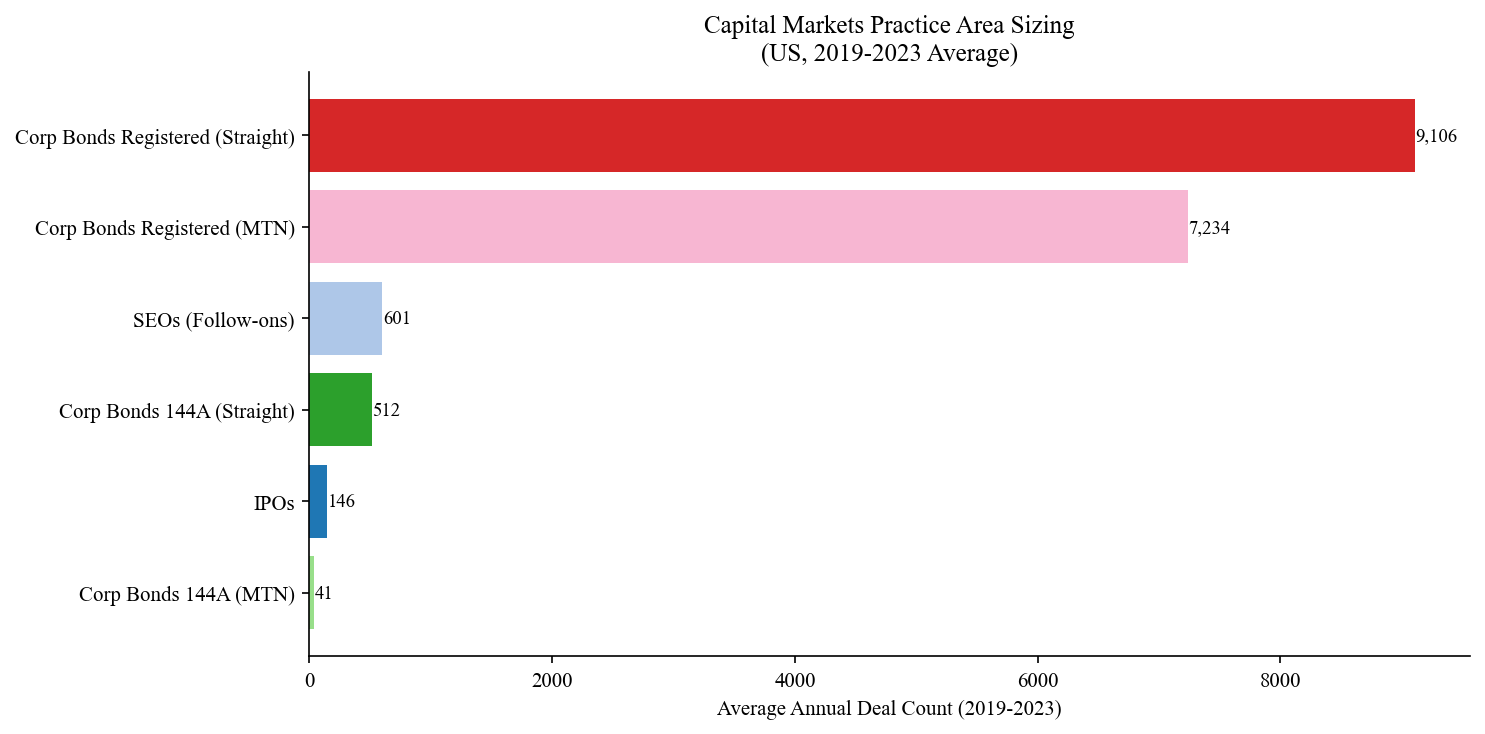

Saved: /tmp/capital_markets_sizing.png

KEY FINDING: 144A bond issuances dwarf IPOs and SEOs in deal count.
The typical capital markets lawyer does far more bond/144A work than IPO work.


In [15]:
# Horizontal bar chart: capital markets practice area by deal count
fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {
    'IPOs': '#1f77b4',
    'SEOs (Follow-ons)': '#aec7e8',
    'Corp Bonds 144A (Straight)': '#2ca02c',
    'Corp Bonds 144A (MTN)': '#98df8a',
    'Corp Bonds Registered (Straight)': '#d62728',
    'Corp Bonds Registered (MTN)': '#f7b6d2',
}
col_name = 'Avg Annual Deals (2019-23)'
ax.barh(
    summary['Practice Area'],
    summary[col_name],
    color=[colors_map.get(pa, 'gray') for pa in summary['Practice Area']]
)
ax.set_xlabel('Average Annual Deal Count (2019-2023)')
ax.set_title('Capital Markets Practice Area Sizing\n(US, 2019-2023 Average)')
for i, (_, row) in enumerate(summary.iterrows()):
    ax.text(row[col_name] + 5, i,
            f"{row[col_name]:,}", va='center', fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/tmp/capital_markets_sizing.png', dpi=150, bbox_inches='tight')
plt.savefig('/tmp/capital_markets_sizing.svg', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /tmp/capital_markets_sizing.png')
print()
print('KEY FINDING: 144A bond issuances dwarf IPOs and SEOs in deal count.')
print('The typical capital markets lawyer does far more bond/144A work than IPO work.')